# This script is to read in the .prof and measurement files for comparisons

In [2]:
import pandas as pd 

import glob
from pathlib import Path
import numpy as np

import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import simple_norm
from astropy.stats import sigma_clip

import matplotlib.pyplot as plt

import sys
import os

from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import FlatLambdaCDM
h=0.7
cosmo=FlatLambdaCDM(H0=h*100, Om0=0.3)

In [3]:
outdir = Path('/home/ppztk1/Erosita/Outputs_Clusters/')
cluster_id = 'cluster'
filter_name = 'H'

prefixes = ["no_noise", "random_field_growth_0.25", "random_field_growth_0.5", "random_field_growth_1"]

pixelscale = 0.3  # arcsec/pix
cluster_z = 0.3
arcsec_to_kpc = cosmo.arcsec_per_kpc_proper(cluster_z).value

prefix_colors = {
    "fluctuations": "tab:orange",   # corresponds to "" prefix
    "no_noise": "teal",
    "loaded_mask": "tab:green",
    "random_field": "hotpink",
    "random_field_growth_0.25":"red",
    "random_field_growth_0.5":"gold",
    "random_field_growth_1":"salmon",
    "random_field_growth_1.25":"purple",

}

prof_style = {"linestyle": "-", "marker": "o"}       
meas_style = {"linestyle": "--", "marker": "s"}    


profiles = []      # From .prof files
measurements = []  # From Profile_measurements_*.csv

for prefix in prefixes:
    label = prefix if prefix else "fluctuations"

    prof_file = outdir / cluster_id / "autoprof_results" / f"{cluster_id}_{filter_name}{'_' + prefix if prefix else ''}.prof"
    if prof_file.exists():
        prof = pd.read_csv(prof_file, skiprows=1)
        prof["R_kpc"] = prof["R"] / arcsec_to_kpc
        profiles.append((label, prof))
    else:
        print(f"Profile file not found: {prof_file}")


    meas_file = outdir / cluster_id / (f"Profile_measurements_{prefix}.csv" if prefix else "Profile_measurements.csv")
    if meas_file.exists():
        meas = pd.read_csv(meas_file)
        meas["R_kpc"] = meas["Radial_Bin_Centre_pix"] * pixelscale / arcsec_to_kpc
        measurements.append((label, meas))
    else:
        print(f"Measurement file not found: {meas_file}")

# Plotting SB profiles

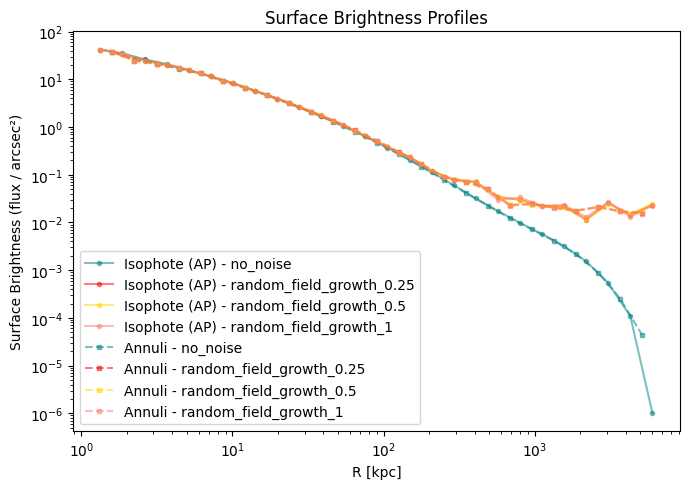

In [8]:

fig, ax = plt.subplots(figsize=(7, 5))

# AP profile isophote measurements

for label, prof in profiles:
    color = prefix_colors.get(label, "black")
    ax.plot(
        prof["R_kpc"], prof["I"],
        label=f"Isophote (AP) - {label}",
        color=color,
        linestyle=prof_style["linestyle"],
        marker=prof_style["marker"],
        ms=3,
        alpha=0.5
    )

#  annuli measurements
for label, meas in measurements:
    color = prefix_colors.get(label, "black")
    ax.plot(
        meas["R_kpc"], meas["Clipped_median_flux_annulus"],
        label=f"Annuli - {label}",
        color=color,
        linestyle=meas_style["linestyle"],
        marker=meas_style["marker"],
        ms=3,
        alpha=0.5
    )

ax.set_xlabel("R [kpc]")
ax.set_ylabel(r"Surface Brightness (flux / arcsec²)")
ax.set_title("Surface Brightness Profiles")
ax.set_xscale('log')
ax.set_yscale('log')
# ax.set_xlim(0,150)
# ax.set_ylim(1,)

ax.legend()
plt.tight_layout()
# plt.savefig(outdir / cluster_id / "SB_profile_comparisons.pdf")

plt.show()



# Plotting shape profiles


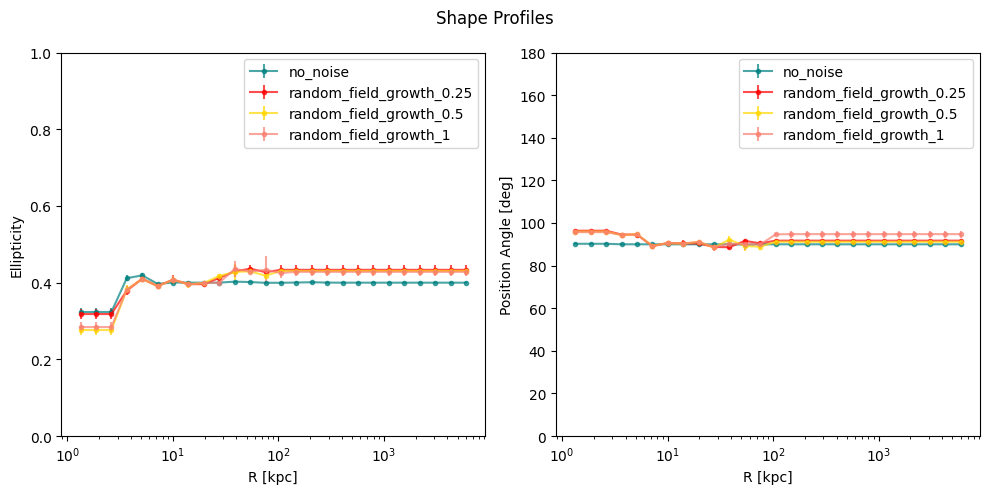

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True)

for label, prof in profiles:
    color = prefix_colors.get(label, "black")
    ax[0].errorbar(
        prof["R_kpc"], prof["ellip"], yerr=prof["ellip_e"],
        label=label,
        fmt=prof_style["marker"],
        color=color,
        linestyle=prof_style["linestyle"],
        ms=3, alpha=0.7
    )
    ax[1].errorbar(
        prof["R_kpc"], prof["pa"], yerr=prof["pa_e"],
        label=label,
        fmt=prof_style["marker"],
        color=color,
        linestyle=prof_style["linestyle"],
        ms=3, alpha=0.7
    )

ax[0].set_xlabel("R [kpc]")
ax[0].set_ylabel("Ellipticity")
ax[0].set_ylim(0, 1)
ax[0].legend()
ax[0].set_xscale('log')


ax[1].set_xlabel("R [kpc]")
ax[1].set_ylabel("Position Angle [deg]")
ax[1].set_ylim(0, 180)
ax[1].legend()
ax[1].set_xscale('log')

fig.suptitle("Shape Profiles")
plt.tight_layout()
# plt.savefig(outdir / cluster_id / "Shape_comparisons.pdf")
plt.show()


# Fractional difference between a reference profile from Annuli method and the rest of the test profiles from the same method

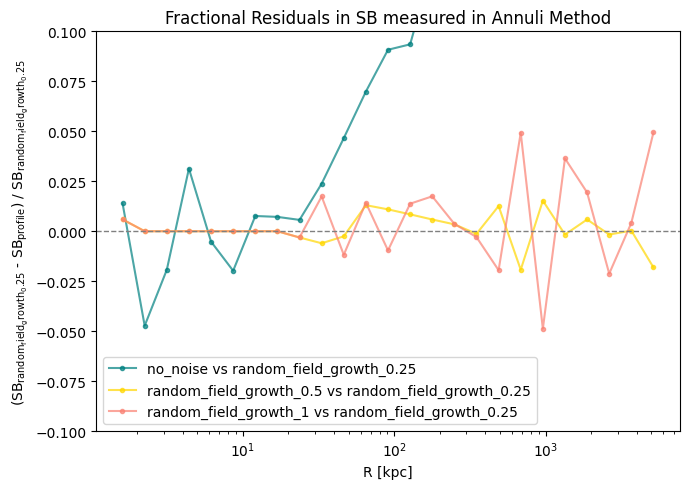

In [16]:
reference_label = "random_field_growth_0.25"

meas_dict = {label: meas for label, meas in measurements}

if reference_label not in meas_dict:
    raise ValueError(f"Reference label '{reference_label}' not found in measurements!")

ref_meas = meas_dict[reference_label]

ref_r_flux = dict(zip(ref_meas["R_kpc"], ref_meas["Clipped_median_flux_annulus"]))

fig, ax = plt.subplots(figsize=(7, 5))

for label, meas in measurements:
    if label == reference_label:
        continue

    other_r = meas["R_kpc"].values
    other_flux = meas["Clipped_median_flux_annulus"].values

    common_r = np.array([r for r in other_r if r in ref_r_flux])
    
    if len(common_r) == 0:
        print(f"No common radii found between '{reference_label}' and '{label}'")
        continue

    ref_flux_vals = np.array([ref_r_flux[r] for r in common_r])
    other_flux_vals = np.array([meas.loc[meas["R_kpc"] == r, "Clipped_median_flux_annulus"].values[0] for r in common_r])

    residual_fraction = (ref_flux_vals - other_flux_vals) / ref_flux_vals

    color = prefix_colors.get(label, "black")
    ax.plot(
        common_r, residual_fraction,
        label=f"{label} vs {reference_label}",
        color=color,
        linestyle="-",
        marker="o",
        ms=3,
        alpha=0.7
    )

ax.axhline(0, color="gray", linestyle="--", lw=1)
ax.set_xscale('log')
ax.set_xlabel("R [kpc]")
ax.set_ylabel(
    fr"(SB$\rm _{{{reference_label}}}$ - SB$\rm _{{profile}}$) / SB$\rm _{{{reference_label}}}$")
    
ax.set_title(f"Fractional Residuals in SB measured in Annuli Method")
ax.legend()

# ax.set_xlim(0,300)
ax.set_ylim(-0.1,.1)
plt.tight_layout()
plt.show()


# Fractional change in SB between a given profile from isophote method and the rest 

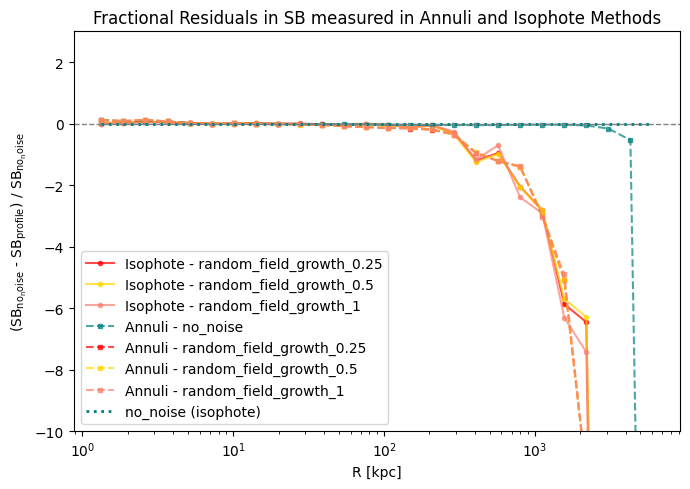

In [17]:
reference_label = "no_noise"

prof_dict = {label: prof for label, prof in profiles}
if reference_label not in prof_dict:
    raise ValueError(f"Reference label '{reference_label}' not found in profiles!")

ref_prof = prof_dict[reference_label]
ref_r = ref_prof["R_kpc"].values
ref_flux = ref_prof["I"].values

fig, ax = plt.subplots(figsize=(7, 5))

#  Comparing other isophote profile measurements 
for label, prof in profiles:
    if label == reference_label:
        continue

    other_r = prof["R_kpc"].values
    other_flux = prof["I"].values

    interp_flux = np.interp(ref_r, other_r, other_flux)
    residual_fraction = (ref_flux - interp_flux) / ref_flux

    color = prefix_colors.get(label, "black")
    ax.plot(
        ref_r, residual_fraction,
        label=f"Isophote - {label}",
        color=color,
        linestyle="-",
        marker="o",
        ms=3,
        alpha=0.7
    )

#  Compareing annuli profile measurements 
for label, meas in measurements:
    other_r = meas["R_kpc"].values
    other_flux = meas["Clipped_median_flux_annulus"].values

    interp_flux = np.interp(ref_r, other_r, other_flux)
    residual_fraction = (ref_flux - interp_flux) / ref_flux

    color = prefix_colors.get(label, "black")
    ax.plot(
        ref_r, residual_fraction,
        label=f"Annuli - {label}",
        color=color,
        linestyle="--",
        marker="s",
        ms=3,
        alpha=0.7
    )

ax.plot(
    ref_r, np.zeros_like(ref_r),
    label=f"{reference_label} (isophote)",
    color=prefix_colors.get(reference_label, "gray"),
    linestyle="dotted",
    linewidth=2
)

# Plot settings
ax.axhline(0, color="gray", linestyle="--", lw=1)
ax.set_xscale('log')
ax.set_xlabel("R [kpc]")

ax.set_ylabel(
    fr"(SB$\rm _{{{reference_label}}}$ - SB$\rm _{{profile}}$) / SB$\rm _{{{reference_label}}}$"
)
ax.set_title(f"Fractional Residuals in SB measured in Annuli and Isophote Methods")
ax.set_ylim(-10,3)

ax.legend()
plt.tight_layout()
plt.show()
